# CNN

Implementation of a small Convolutional Neural Network for image classification on CIFAR-10.

The CNN is the historical successor of the MLP for vision (LeNet 1998, AlexNet 2012, VGG, ResNet...). Instead of flattening the image, it slides learnable **kernels** over the 2D grid : local connectivity + weight sharing give it a strong spatial inductive bias and far fewer parameters than an MLP. It sits between the MLP (notebook 1) and the ViT (notebook 3) in the trajectory **MLP → CNN → ViT**.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math
import os

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "DATA"))
CKPT_DIR = './checkpoints/2_CNN'
os.makedirs(CKPT_DIR, exist_ok=True)

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device = {device}")

device = cuda


---
# 0. Dataset

CIFAR-10 : 60k color images of size 32×32 split into 50k training samples and 10k test samples, across 10 classes : airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

In [2]:
BATCH_SIZE = 128
IMG_SIZE   = 32
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_set = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True,  download=True, transform=train_tf)
test_set  = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_tf)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

sample_img, _ = train_set[0]
CHANNELS, H, W = sample_img.shape
NUM_CLASSES    = len(train_set.classes)
print(f"train {len(train_set)} | test {len(test_set)} | classes {NUM_CLASSES}")

train 50000 | test 10000 | classes 10


## Data augmentation

To prevent overfitting on the 50k training images, two stochastic transforms :

`RandomHorizontalFlip()` : flips horizontally with probability 0.5 → invariance to left/right orientation.

`RandomCrop(32, padding=4)` : pads with 4 zero pixels then crops back 32×32 → invariance to small translations.

Test images get only `ToTensor` + `Normalize` (deterministic evaluation).

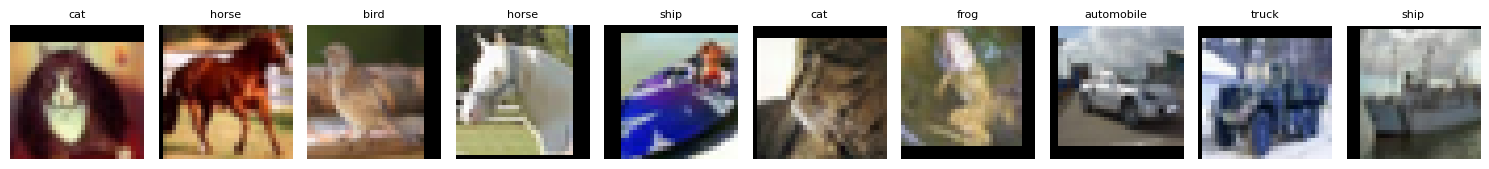

In [3]:
def unnorm(img):
    m = torch.tensor(MEAN).view(3, 1, 1)
    s = torch.tensor(STD).view(3, 1, 1)
    return (img * s + m).clamp(0, 1)

indices = torch.randint(0, len(train_set), (10,))
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, idx in enumerate(indices):
    img, label = train_set[idx]
    axes[i].imshow(unnorm(img).permute(1, 2, 0).numpy())
    axes[i].set_title(train_set.classes[label], fontsize=8)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

---
# 1. CNN architecture

A small VGG-style CNN : stacked $3\times3$ convolutions (each followed by BatchNorm + ReLU), with max-pooling to halve the spatial size, then global average pooling and a linear head.

**Convolution block** : `Conv2d(c_in, c_out, 3, padding=1, bias=False) → BatchNorm2d → ReLU`. Padding 1 keeps the spatial size ; the kernel is shared across all positions (weight sharing) → translation-equivariant and parameter-efficient.

| Step | Operation | Shape |
|---|---|---|
| Input | image | $(B, 3, 32, 32)$ |
| block(3→32), block(32→32), MaxPool | conv ×2 + downsample | $(B, 32, 16, 16)$ |
| block(32→64), block(64→64), MaxPool | conv ×2 + downsample | $(B, 64, 8, 8)$ |
| block(64→128), block(128→128), MaxPool | conv ×2 + downsample | $(B, 128, 4, 4)$ |
| AdaptiveAvgPool2d(1) | global average pool | $(B, 128, 1, 1)$ |
| flatten + Linear(128 → num_classes) | classification head | $(B, \text{num\_classes})$ |

Each conv uses `bias=False` because the following BatchNorm has its own shift parameter. Downsampling by max-pooling grows the receptive field : after the 3 pooling stages, a single output neuron sees the whole image.

In [4]:
# Hyperparameters
NUM_EPOCHS = 60
LR         = 1e-3
WEIGHT_DECAY = 5e-4

In [5]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        def block(c_in, c_out):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
            )

        self.features = nn.Sequential(
            block(3, 32),   block(32, 32),   nn.MaxPool2d(2),   # 32x32 -> 16x16
            block(32, 64),  block(64, 64),   nn.MaxPool2d(2),   # 16x16 -> 8x8
            block(64, 128), block(128, 128), nn.MaxPool2d(2),   # 8x8   -> 4x4
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(128, num_classes)

    def forward(self, x):                 # (B, 3, 32, 32)
        x = self.features(x)              # (B, 128, 4, 4)
        x = self.pool(x).flatten(1)       # (B, 128)
        return self.head(x)               # (B, num_classes)


model = CNN(NUM_CLASSES).to(device)

params = sum(p.numel() for p in model.parameters())

# Theoretical parameter count : conv (no bias) + BatchNorm (2*C) per block, + linear head
def conv_bn(c_in, c_out, k=3):
    return c_out * c_in * k * k + 2 * c_out

chans = [(3, 32), (32, 32), (32, 64), (64, 64), (64, 128), (128, 128)]
conv_params = sum(conv_bn(ci, co) for ci, co in chans)
head_params = 128 * NUM_CLASSES + NUM_CLASSES
params_th   = conv_params + head_params

print(f"conv+BN params : {conv_params:,}")
print(f"head params    : {head_params:,}")
print(f"empirical : {params:,}")
print(f"theory    : {params_th:,}")
print(f"match     : {params == params_th}")

conv+BN params : 287,456
head params    : 1,290
empirical : 288,746
theory    : 288,746
match     : True


---
# 2. Training

Training with **cross-entropy** as criterion and **AdamW** as optimizer (see notebook 1 for the maths of both). A **convergence criterion** is used : early stopping when the best test accuracy has not improved for `PATIENCE` epochs, and the final slope (%/epoch) quantifies the plateau.

In [6]:
def slope_per_epoch(values, window=5):
    if len(values) < 2:
        return float('inf')
    w = min(window, len(values))
    y = np.array(values[-w:]); x = np.arange(w)
    return float(np.polyfit(x, y, 1)[0])


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

PATIENCE = 8
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []
best_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    train_losses.append(tr_loss); test_losses.append(te_loss)
    train_accs.append(tr_acc);   test_accs.append(te_acc)
    print(f"epoch {epoch:2d}/{NUM_EPOCHS} | train {tr_loss:.4f} {tr_acc*100:.1f}% | test {te_loss:.4f} {te_acc*100:.1f}%")

    if te_acc > best_acc:
        best_acc = te_acc
        torch.save({'epoch': epoch, 'model': model.state_dict(),
                    'train_losses': train_losses, 'test_losses': test_losses,
                    'train_accs':   train_accs,   'test_accs':   test_accs},
                   os.path.join(CKPT_DIR, 'cnn_best.pt'))

    best_epoch = test_accs.index(max(test_accs))
    if (len(test_accs) - 1 - best_epoch) >= PATIENCE:
        print(f"  early stop : converged (no improvement for {PATIENCE} epochs)")
        break

print(f"\nbest test acc : {max(test_accs)*100:.2f}%")
print(f"converged at  : epoch {test_accs.index(max(test_accs))+1}")
print(f"final slope   : {slope_per_epoch([a*100 for a in test_accs]):.3f} %/epoch")

epoch  1/60 | train 1.3083 52.5% | test 1.3326 53.3%
epoch  2/60 | train 0.9038 68.1% | test 1.2180 58.8%
epoch  3/60 | train 0.7509 73.6% | test 0.9771 67.8%
epoch  4/60 | train 0.6532 77.2% | test 0.7962 72.7%
epoch  5/60 | train 0.5984 79.2% | test 0.6365 78.5%
epoch  6/60 | train 0.5578 80.8% | test 0.6963 77.3%
epoch  7/60 | train 0.5195 81.9% | test 0.5814 79.9%
epoch  8/60 | train 0.4893 83.1% | test 0.7680 76.1%
epoch  9/60 | train 0.4620 84.1% | test 0.7878 75.2%
epoch 10/60 | train 0.4412 84.8% | test 0.5276 82.0%
epoch 11/60 | train 0.4211 85.3% | test 0.6036 79.5%
epoch 12/60 | train 0.4028 86.1% | test 0.5233 83.0%
epoch 13/60 | train 0.3874 86.5% | test 0.6895 79.1%
epoch 14/60 | train 0.3731 87.0% | test 0.5279 83.1%
epoch 15/60 | train 0.3589 87.5% | test 0.5783 81.8%
epoch 16/60 | train 0.3488 87.9% | test 0.4687 84.8%
epoch 17/60 | train 0.3385 88.4% | test 0.5054 84.0%
epoch 18/60 | train 0.3259 88.7% | test 0.4501 85.5%
epoch 19/60 | train 0.3143 89.1% | test 0.4503

## Curves

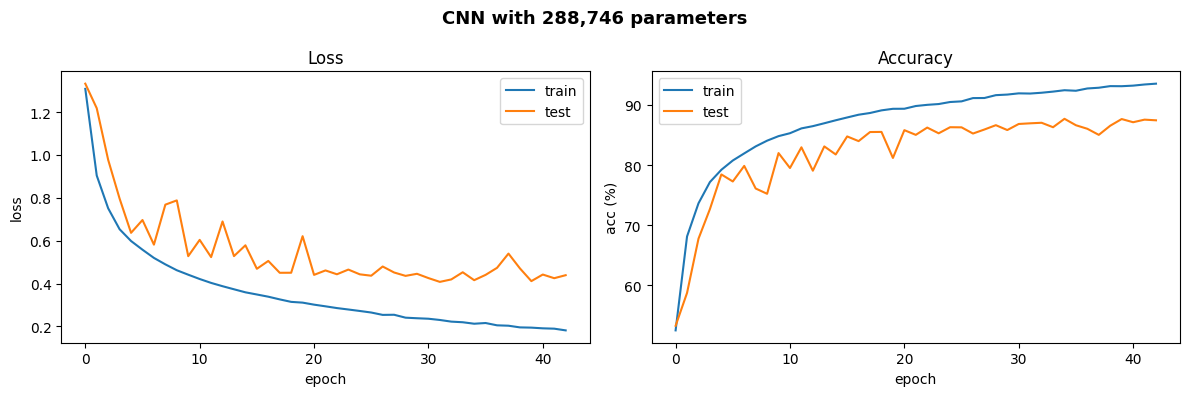

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='train'); ax1.plot(test_losses, label='test')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend(); ax1.set_title('Loss')
ax2.plot([a*100 for a in train_accs], label='train'); ax2.plot([a*100 for a in test_accs], label='test')
ax2.set_xlabel('epoch'); ax2.set_ylabel('acc (%)'); ax2.legend(); ax2.set_title('Accuracy')
plt.suptitle(f'CNN with {params:,} parameters', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
# 3. Results

Plot 10 random predictions from the test set

loaded best CNN | epoch 35 | best test acc 87.70%


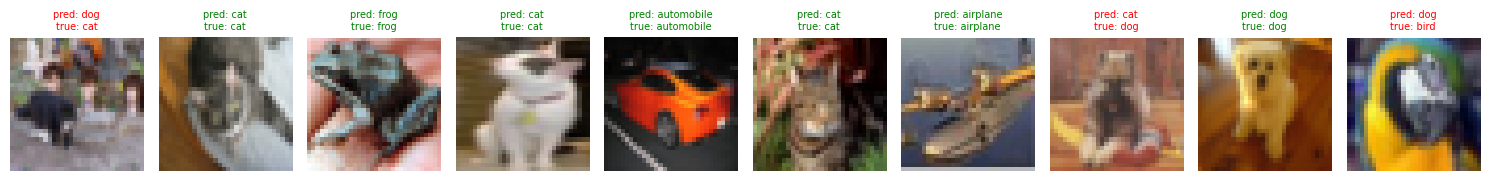

In [9]:
ckpt = torch.load(os.path.join(CKPT_DIR, 'cnn_best.pt'), map_location=device)
model.load_state_dict(ckpt['model'])
print(f"loaded best CNN | epoch {ckpt['epoch']} | best test acc {max(ckpt['test_accs'])*100:.2f}%")

model.eval()
classes = test_set.classes
indices = torch.randint(0, len(test_set), (10,))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, idx in enumerate(indices):
    img, true_label = test_set[idx]
    with torch.no_grad():
        logits = model(img.unsqueeze(0).to(device))
        pred = logits.argmax(dim=1).item()
    axes[i].imshow(unnorm(img).permute(1, 2, 0).numpy())
    color = 'green' if pred == true_label else 'red'
    axes[i].set_title(f"pred: {classes[pred]}\ntrue: {classes[true_label]}",
                       fontsize=7, color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()